4.1 그래프 그리기

In [ ]:
#주로 사용하는 library import
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

#실행 4_1_1. sin 함수 그래프 그리기

In [ ]:
print(np.arange(start=0,stop=20, step=1))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


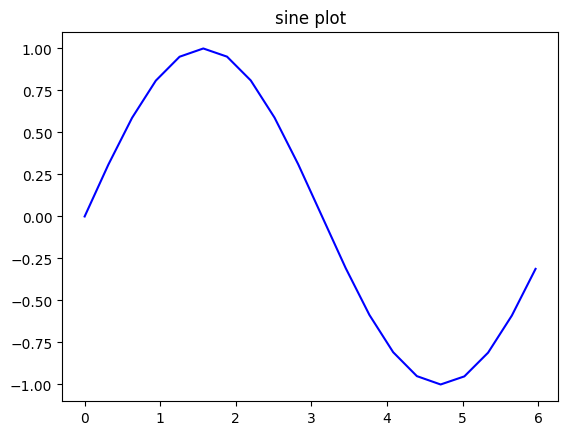

In [ ]:
#data
pi=3.14
x=np.arange(start=0,stop=20, step=1)*pi/10  #0보다 크거나 같고, 20보다 작은 값
y=np.sin(x)
plt.plot(x,y, color= 'blue') #sin 함수 그리기
plt.title('sine plot')
plt.show()

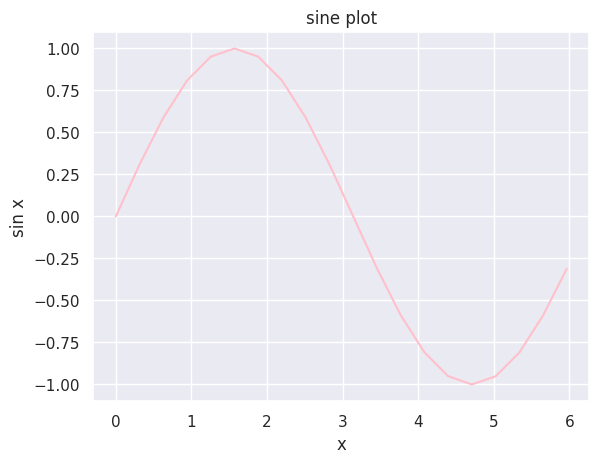

In [ ]:
sns.set_theme() #부드러운 색상과 격자 배경이 적용
plt.plot(x,y, color= 'pink')
plt.title('sine plot')
plt.xlabel('x')
plt.ylabel('sin x')
plt.show()

#실행 4_1_2. 표준정규분포 함수 그래프 그리기

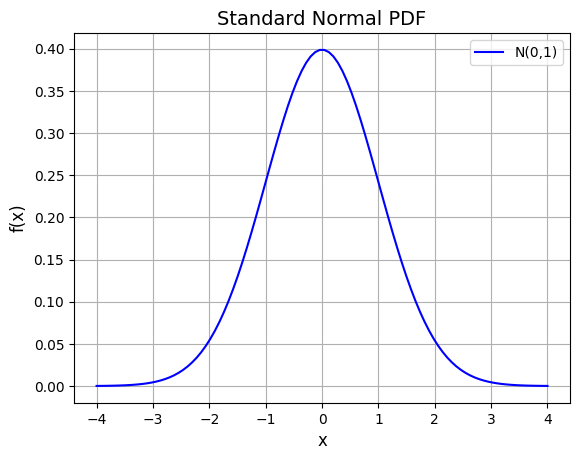

In [ ]:
from scipy.stats import norm #표준정규분포 확률밀도함수
#data
x = np.linspace(-4, 4, 100) #구간 -4 ~ 4 까지 같은 간격을 가진 100개 점
y = norm.pdf(x, loc=0, scale=1) #평균=0, 표준편차=1 인 정규분포의 확률
sns.reset_defaults() #seaborn 함수 해제

# 그래프 그리기
plt.plot(x, y,  label='N(0,1)',color="blue")
plt.title("Standard Normal PDF", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

#연습4_1

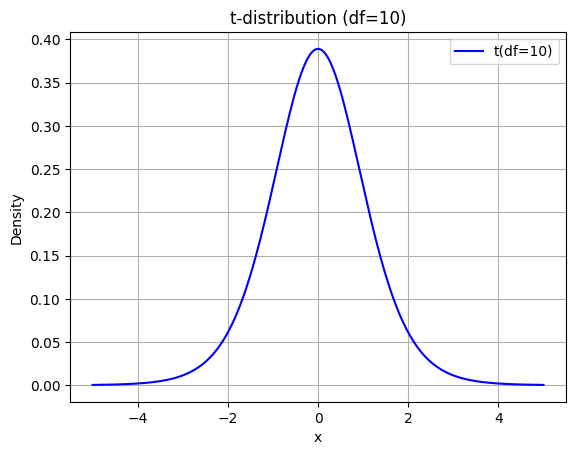

In [ ]:
from scipy.stats import t, chi2

#x
x1=np.linspace(-5,5,200)

#자유도 10 t분포
y_t10=t.pdf(x1,df=10)

plt.plot(x1,y_t10, label='t(df=10)', color='blue')
plt.title('t-distribution (df=10)')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()

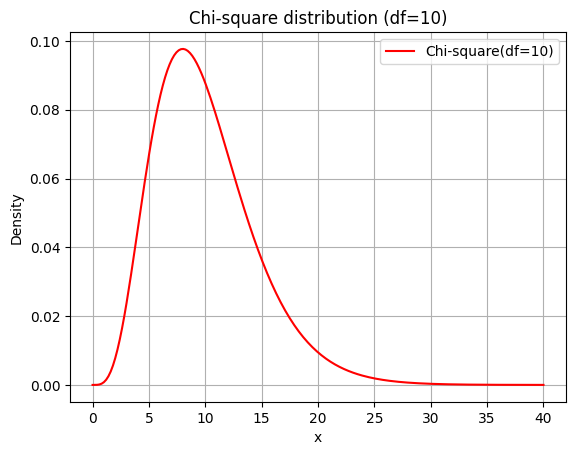

In [ ]:
#x 범위 설정
x2= np.linspace(0, 40, 200)

#자유도 10 카이제곱 분포
y_chi10=chi2.pdf(x2,df=10)

plt.plot(x2, y_chi10,label='Chi-square(df=10)', color='red')
plt.title('Chi-square distribution (df=10)')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()

# 실행4_2_1. 막대 그래프 그리기

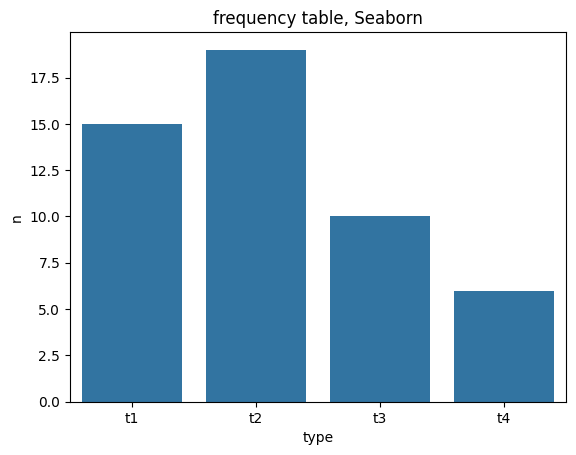

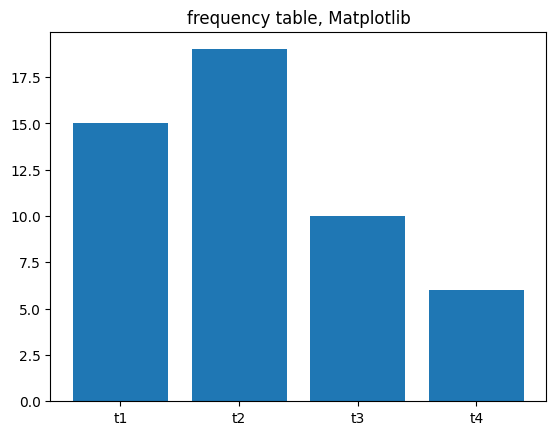

In [ ]:
#data : 빈도표 형식
df_freq = pd.DataFrame({'type': ['t1', 't2', 't3', 't4'], 'n': [15, 19, 10, 6]})

#seaborn 막대그래프
sns.barplot(x='type', y='n', data=df_freq)
plt.title('frequency table, Seaborn')
plt.show() #그래프 출력 명령

#matplotlib 막대그래프
plt.bar(df_freq['type'], df_freq['n'])
plt.title('frequency table, Matplotlib')
plt.show()

In [ ]:
#data : raw data 형식 (students 데이터)
from google.colab import drive

#구글 드라이브 마운트(연결)
drive.mount('/content/drive')

#드라이브에 저장된 파일 경로 지정
file_path = '/content/drive/MyDrive/Colab_ex_data/students.csv'

#데이터프레임 만들기
df_students = pd.read_csv(file_path)
print(df_students.head())

Mounted at /content/drive


KeyboardInterrupt: 

In [ ]:
#seaborn 막대그래프
sns.countplot(x='grade', data=df_students) #raw data는 빈도를 세야 하므로 barplot이 아니라 countplot을 사용함
plt.title('Students by Grade :raw data, Seaborn')
plt.show()

In [ ]:
counts = df_students['grade'].value_counts().sort_index() # grade별 학생수 집계
print(counts)
plt.bar(counts.index, counts.values)
plt.title('Students by Grade :raw data, Matplotlib')
plt.show()

#실행 4_2_2. 파이도표 그리

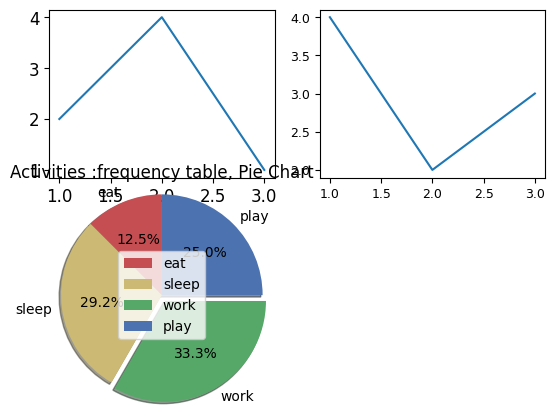

In [ ]:
#data : 빈도표 형식
activities =['eat', 'sleep', 'work', 'play']
slices =[3, 7, 8, 6]  #빈도를 나타내는 변수
colors = ['r', 'y', 'g', 'b']  #파이도표의 색깔 옵션을 지정하기 위해서 만들어놓음

#Pie chart
plt.pie(slices, #파이 조각 크기, 비율계산해서 반영
 labels = activities, #파이의 라벨로 나타날 수 있게 지정해줌
 colors = colors,
 startangle = 90, #파이 시작 각도, 90이면 12시 방향부터 시작
 shadow = True, #그림자 효과
 explode = (0, 0, 0.1, 0), #특정 조각을 원에서 "튀어나오게" 분리, 3번째 조각(0.1)만 10% 밖으로
 radius = 1.5, #파이 차트 반지름, 기본=1.0
 autopct ='%3.1f%%')  #1:숫자의 최소자리수(3,4,5를 써도 됨) + .1: 소수점 1자리까지 출력 + f: 실수로 표현 (d: 정수) + %: 기호 붙이기
plt.legend(loc="center") #라벨옵션 center, best, lower left, ...
plt.title('Activities :frequency table, Pie Chart', y=1.15)  #y=1.15: 아래 위로 얼마나 띄울건지 지정, 없으면 그래프랑 제목이 겹칠 수 있음
#y는 제목의 세로 좌표(상대값)
plt.show()

In [ ]:
#data : raw data 형식 (students 데이터)
counts = df_students['grade'].value_counts().sort_index() # grade별 학생수 집계
plt.pie(counts.values,
 labels=counts.index,
 autopct='%1.0f%%',
 startangle=90,
 counterclock=False)  #시계방향으로 파이를 표시함
plt.title('Students by Grade :raw data, Pie Chart')
plt.show()

# 실행4_2_3. 모자이크 그림 그리기

In [ ]:
from statsmodels.graphics.mosaicplot import mosaic

#data
airplane={('survive','male'):50, ('survive','female'):30,
('death', 'male'):50, ('death','female'):70} #딕셔너리 형태의 data
#두개의 범주형 변수가 있음

#mosaic plot
mosaic(airplane)
plt.show ()

In [ ]:
#data : raw data 형식 (students 데이터)
#grade, class 학생수 모자이크 도표 그리기
mosaic(df_students, ['grade','major'])  #따로 count할 필요없이 알아서 해줌
plt.show()

#연습 4_2

In [ ]:
#데이터 불러오기
df_titanic=sns.load_dataset('titanic')  #seaborn 제공 데이터셋, 바로 DataFrame 형태로 출력
print(df_titanic)
print(df_titanic.info())

#막대그래프 (class별 승객 수)
sns.countplot(x='class',data=df_titanic)
plt.show()

In [ ]:
counts=df_titanic['class'].value_counts().sort_index()
plt.bar(counts.index,counts.values)
plt.show()

In [ ]:
#파이도표 (class별 비율)
counts=df_titanic['class'].value_counts().sort_index() #class별 탑승객수 집계
print(counts)

plt.pie(counts.values,
        labels=counts.index,
        autopct='1.01%%',
        startangle=90,
        counterclock=False)
plt.show()

In [ ]:
mosaic(df_titanic,['class','alive'])
plt.show()

# 실행 4_3_1. 히스토그램 그리기

In [ ]:
#data
x=np.random.standard_normal(100) #표준정규분포 난수 100개 생성

#seaborn histogram
sns.histplot(x) #distplot 권장되지 않음, 삭제가능성
plt.show()

#matplotlib histogram
plt.hist(x, bins=20) #계급구간수 조정가능
plt.show()

#y축 density
plt.hist(x, density=True, color='pink')  #density=True: 빈도가 아니라 상대도수를 계산해서 출력해줌
plt.show()

In [ ]:
#students 데이터 math 변수의 히스토그램
plt.hist(df_students['math'])
plt.show()

In [ ]:
#연속형 변수들만 선택하여 한번에
num_cols = ['math', 'english', 'science']
df_students[num_cols].hist(bins=15) #pandas의 hist
plt.show()

#실행 4_3_2. 상자그림 그리기

            group           x
count  100.000000  100.000000
mean     1.500000    0.041250
std      0.502519    0.850109
min      1.000000   -2.339802
25%      1.000000   -0.566626
50%      1.500000   -0.005882
75%      2.000000    0.603517
max      2.000000    2.172713


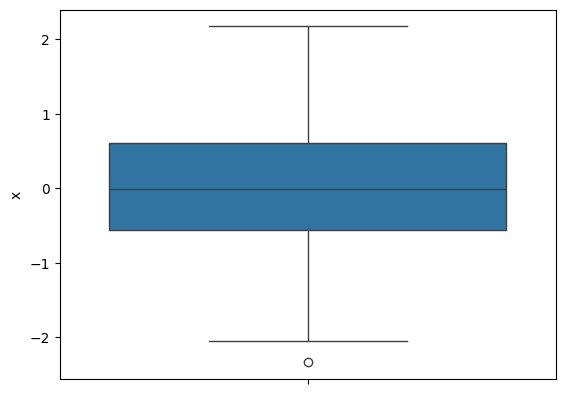

In [ ]:
#data
group = [1]*50 + [2]*50 #1,2 50개씩 생성
x=np.random.standard_normal(100) #정규분포 난수 100개 생성
df = pd.DataFrame({'group': group,'x': x}) #데이터프레임 만들기

#boxplot
print(df.describe()) #sp의 describe와는 출력되는 통계량이 상이
sns.boxplot(y='x', data=df) #상자그림
plt.show()

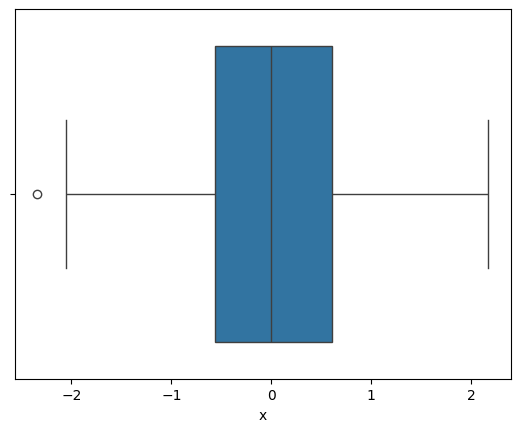

In [ ]:
sns.boxplot(x='x', data=df) #상자그림
plt.show()

          x                                                             \
      count      mean      std       min       25%       50%       75%   
group                                                                    
1      50.0 -0.024217  0.89128 -2.339802 -0.693482 -0.089692  0.582020   
2      50.0  0.106716  0.81055 -2.049913 -0.405900  0.060859  0.615276   

                 
            max  
group            
1      2.172713  
2      1.868354  


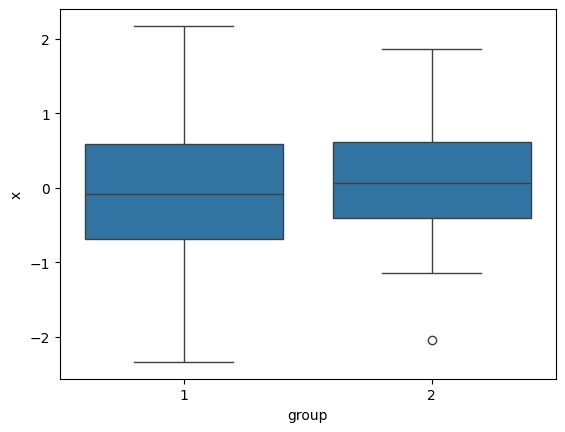

In [ ]:
#boxplot by Group
print(df.groupby('group').describe()) #그룹별 통계량
sns.boxplot(x='group', y='x', data=df) #상자그림
plt.show()

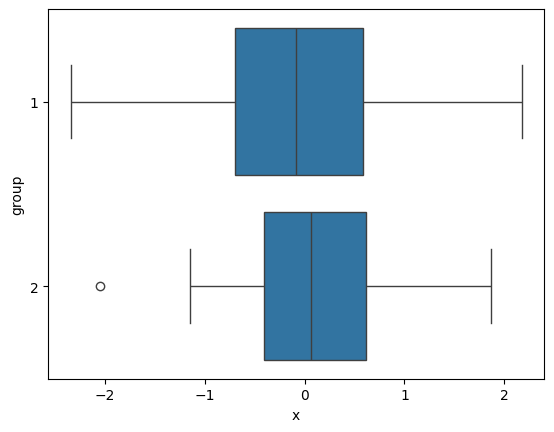

In [ ]:
df['group']=df['group'].astype('category')
sns.boxplot(x='x',y='group',data=df)
plt.show()

In [ ]:
#students 데이터 math 변수의 상자그림
sns.boxplot(x='math', data=df_students)
plt.show()

#students 데이터 math 변수의 grade 그룹별 상자그림
sns.boxplot(x='math',y='grade', data=df_students)
plt.show()

NameError: name 'df_students' is not defined

In [ ]:
#연속형 변수들만 선택하여 한번에
num_cols = ['math', 'english', 'science']
sns.boxplot(data=df_students[num_cols])
plt.show()

#실행 4_3_3. 바이올린 그림 그리기

In [ ]:
#data
group = [1]*50 + [2]*50    #1,2 50개씩 생성
x=np.random.standard_normal(100)    #정규분포 난수 100개 생성
df = pd.DataFrame({'group': group,'x': x})   #데이터프레임 만들기

In [ ]:
#violinplot
sns.violinplot(x='x', data=df)
plt.show()

In [ ]:
#violinplot by Group
df['group'] = df['group'].astype('category')    #그룹변수는 반드시 범주형이어야 함
sns.violinplot(x='x', y='group', data=df)
plt.show()

In [ ]:
#students 데이터 math 변수의 grade 그룹별 바이올린그림
sns.violinplot(x='math', y='grade', data=df_students)
plt.show()

In [ ]:
sns.violinplot(x=df_students['math'], y=df_students['grade'])
plt.show()

In [ ]:
#연속형 변수들만 선택하여 한번에
num_cols = ['math', 'english', 'science']
sns.violinplot(data=df_students[num_cols])
plt.show()

#실행 4_3_4. 산점도 그리기 (연속형 변수 2개)

In [ ]:
#data
x=[1,2,3,4,5,6,7,8,9,10]
y=[2,4,5,7,6,8,9,11,12,10]

#scatter plot
plt.scatter(x,y)
plt.show()

#Scatter plot customization
plt.scatter(x,y, color='green', marker='D', s=30)   #marker: '*' 별, 's' 사각형, 'D' 다이아몬드, 'x' 엑스 + s: 점크기
plt.show()

In [ ]:
#Scatter plot with regression line
sns.regplot(x=x, y=y, ci=None)   #default ci(신뢰구간)=95, 최소제곱회귀직선 fitting
plt.title('scatter + reg')
plt.show()

In [ ]:
#students 데이터 math vs english 산점도와 최소제곱회귀직선
sns.regplot(x=df_students['math'], y=df_students['english'], ci=None)
plt.show()

In [ ]:
#students 데이터 math vs english 산점도와 최소제곱회귀직선
sns.regplot(x='math', y='english', data=df_students , ci=None)
plt.show()

#실행 4_3_5. 정규확률도 그리기

In [ ]:
 import scipy.stats as stats
 x = np.random.standard_normal(100)

 #정규확률도(Quantile–Quantile plot): 이론적인 분포에서 계산한 분위 수들을 x축으로, 내 데이터로 계산한 분위수들을 y축으로 해서 그린 그림
 stats.probplot(x, dist="norm", plot=plt)  #dist="norm": 비교할 함수  #plot=plt:생성한 데이터로 matplotlib 형식으로 그림을 그려달라는 옵션이므로 없으면 안됨
 plt.title("Q-Q plot")
 plt.show()
 #그래프가 직선에서 벗어나면 데이터가 정규성 만족못한다고(정규분포에서 멀어진다고) 해석

In [ ]:
#students 데이터 math 변수 정규확률도(Quantile–Quantile plot)
stats.probplot(df_students['math'], dist="norm", plot=plt)
plt.show()

#연습 4_3

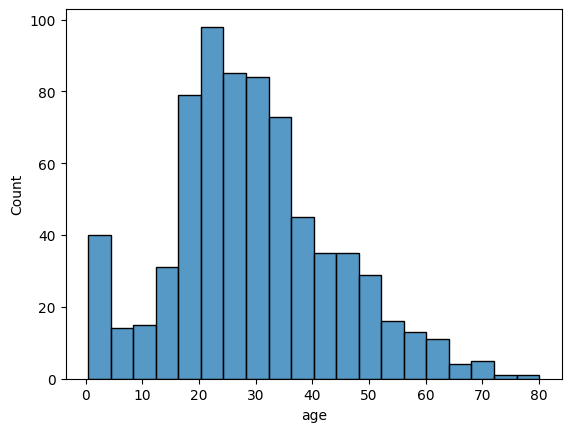

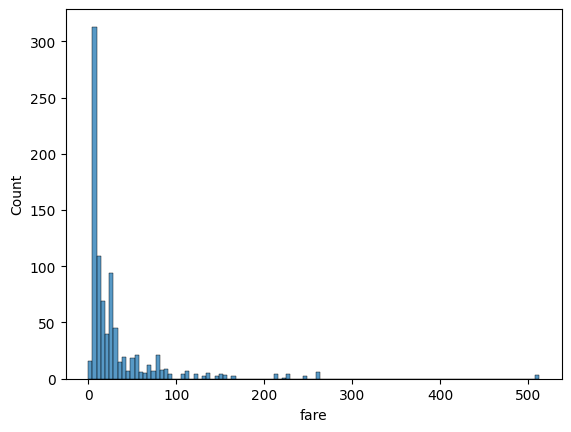

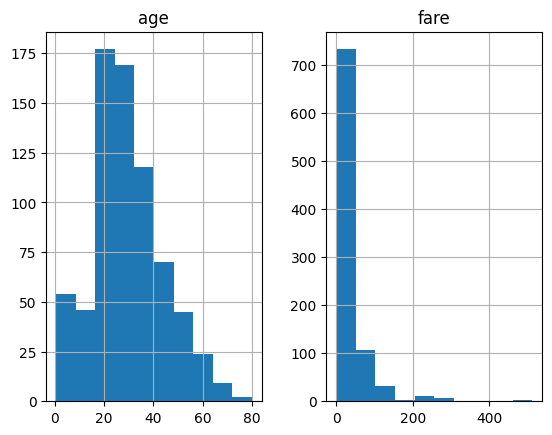

In [ ]:
#데이터 불러오기
df_titanic=sns.load_dataset('titanic')  #seaborn 제공 데이터셋, 바로 DataFrame 형태로 출력

#age 분포 히스토그램
sns.histplot(df_titanic['age'])
plt.show()

#fair 분포 히스토그램
sns.histplot(df_titanic['fare'])
plt.show()

#선택하여 한번에
num_cols=['age','fare']
df_titanic[num_cols].hist()
plt.show()

In [ ]:
#class별 age 분포 상자그림
sns.boxplot(x='class',y='age',data=df_titanic)
plt.show()

#calss별 age 분포 바이올린그림
sns.violinplot(x='age',y='class', data=df_titanic)  #x,y 바꾸면 축 변경
plt.show()

In [ ]:
#age vs fare 산점도
plt.scatter(df_titanic['age'], df_titanic['fare'])
plt.show()

#age vs fare 산점도와 최소제곱회귀직선
sns.regplot(x=df_titanic['age'], y=df_titanic['fare'],ci=None)
plt.show()

In [ ]:
#age 정규확률도 (Q-Q plot)
stats.probplot(df_titanic['age'].dropna(), dist='norm', plot=plt) #age의 결측치 때문에 선이 출력되지 않으므로 df_titanic['age'].dropna()로 결측제거
plt.show()

#실행 4_4_1. 산점도 행렬 그리기

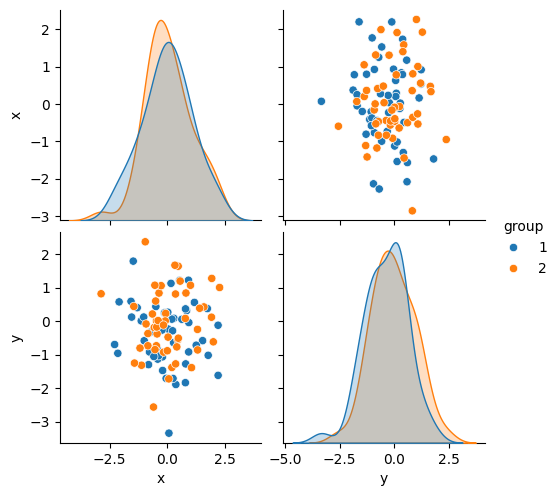

In [ ]:
#data
group = ['1']*50 + ['2']*50     #1,2 50개씩 생성
x=np.random.standard_normal(100)   #정규분포 난수 100개 생성
y=np.random.standard_t(df=10, size=100)     #t분포 난수 100개 생성

df_m = pd.DataFrame({'group': group,'x': x, 'y':y})   #데이터프레임 만들기
sns.pairplot(df_m,  hue='group')     #hue=색상구분기준변수
plt.show()

In [ ]:
#students 데이터 math,english,scince 산점도 행렬
sns.pairplot(df_students[['math','english','science','major']], hue='major')
plt.show()
#or
sns.pairplot(data=df_students, vars=['math','english','science'], hue='major')
plt.show()

NameError: name 'df_students' is not defined

# 실행 4_4_2. 2개 선그래프를 하나의 좌표평면에 그리기

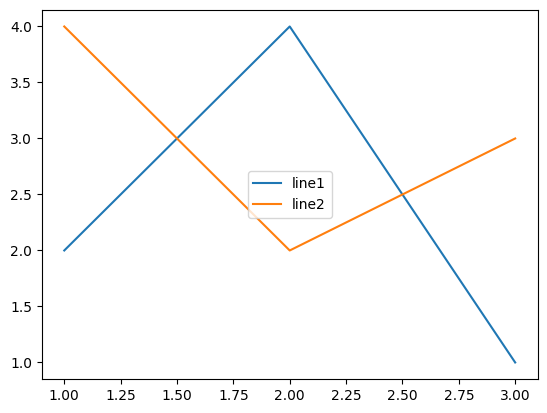

In [ ]:
#data
x1=[1,2,3]
y1=[2,4,1]
plt.plot(x1,y1,label='line1')    #line graph 1

x2=[1,2,3]
y2=[4,2,3]
plt.plot(x2,y2,label='line2')    #line graph 2

plt.legend(loc='center')         #그래프에 라벨 범례 표시하기
plt.show()

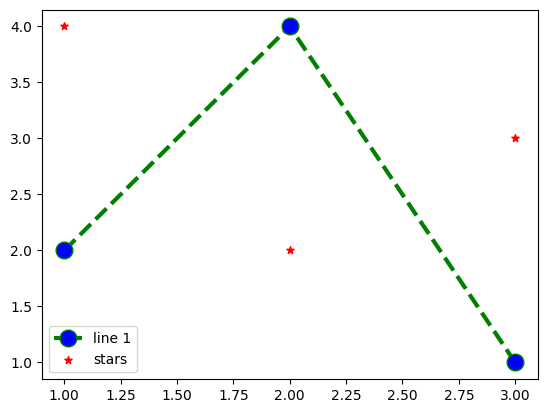

In [ ]:
#그래프 조정
plt.plot (x1, y1, color = 'green', linestyle = 'dashed', linewidth= 3, marker= 'o', markerfacecolor = 'blue', markersize = 12, label= 'line 1')
plt.scatter(x2, y2, label = "stars", color = "red", marker ="*", s=30)
plt.legend(loc='lower left')
plt.show()

#실행 4_4_3. 여러개 그래프 한 화면에 배열

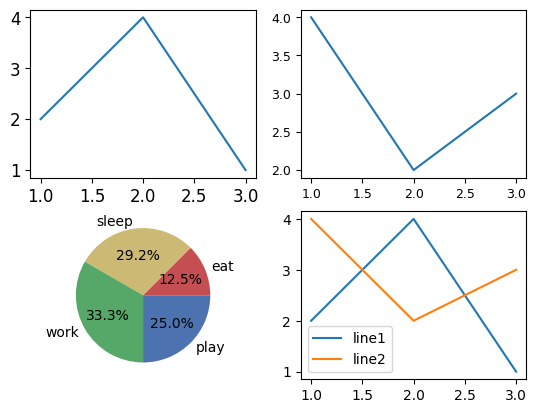

In [ ]:
plt.subplot(2,2,1)     #2*2배열의 1번자리
plt.plot(x1,y1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(2,2,2)      #2*2배열의 2번자리
plt.plot(x2,y2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(2,2,3)      #2*2배열의 3번자리
plt.pie(slices, labels = activities, colors = colors, autopct ='%1.1f%%')

plt.subplot(2,2,4)      #2*2배열의 4번자리
plt.plot(x1,y1,label='line1')
plt.plot(x2,y2,label='line2')
plt.legend()
plt.show()

#실행 4_4_4. 3차원 산점도 그리기

In [ ]:
#data
group = [1]*50 + [2]*50    #1,2 50개씩 생성
x=np.random.standard_normal(100)    #정규분포 난수 100개 생성
y=np.random.standard_t(df=10, size=100)    #t분포 난수 100개 생성
z=np.random.normal(10,3,100)   #평균 10, 표준편차 3인 난수 100개 생성

fig=plt.figure(figsize=(10,10))  #그림 사이즈 지정
ax=fig.add_subplot(111,projection='3d')  #111: 1행 1열 격자 중 1번째 컨버스를 사용하라 (전체 사용함)
ax.scatter(x,y,z)
plt.show()

#연습 4_4

In [ ]:
#산점도 행렬
sns.pairplot(df_titanic[['age','fare','pclass']])
plt.show()

In [ ]:
plt.subplot(3,1,1)
#age 분포 히스토그램
sns.histplot(df_titanic['age'])  #sns.histplot(x='age', data=df_titanic) 이것도 가능: 단일변수일때만!!
plt.show()

plt.subplot(3,1,2)
#class별 age 분포 상자그림
sns.boxplot(x='class',y='age', data=df_titanic)  #변수가 여러개일 때는 sns.xxplot(x='', y='', data=yy) 형식 지켜서 쓰기 (맷플롯립은 plt.xx(yy[''], yy['']) 형식 지켜서 쓰기)
plt.show()

plt.subplot(3,1,3)
#class별 age 분포 바이올린그림
sns.violinplot(x='age',y='class', data=df_titanic) #x,y 바꾸면 축 변경
plt.show()

In [ ]:
sns.histplot(df_titanic['age'])
plt.show()

plt.subplot(3,1,2)
#class별 age 분포 상자그림
sns.boxplot(x='class',y='age', data=df_titanic)
plt.show()

plt.subplot(3,1,3)
#class별 age 분포 바이올린그림
sns.violinplot(x='age',y='class', data=df_titanic) #x,y 바꾸면 축 변경
plt.show()

In [ ]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(df_titanic['age'],df_titanic['fare'],df_titanic['pclass'])
plt.show()

#연습 4_5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

#x구간 (-4~4까지 200개 점)
x=np.linspace(-4,4,200)

#표준정규분포
y_norm=norm.pdf(x, loc=0, scale=1)
plt.plot(x, y_norm, label='Normal(0,1)', color='black', linewidth=2)

#자유도 리스트
dfs=[10,20,30]

#for문으로 t분포 그래프 반복
for df in dfs:
  y_t=t.pdf(x,df=df)
  plt.plot(x,y_t, label=f't(df={df})')  #df값이 변할 때마다 라벨이 변하게 하려면, 맨 앞에 f를 쓰고 {} 사용하면 됨

#그래프 설정
plt.title('t-distribution vs Standard Normal')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

#x구간 (-4~4까지 200개 점)
x=np.linspace(-4,4,200)

#표준정규분포
y_norm=norm.pdf(x, loc=0, scale=1)
t10=t.pdf(x,df=10)
t20=t.pdf(x,df=20)
t30=t.pdf(x,df=30)
plt.plot(x, y_norm,color='black')
plt.plot(x, t10,color='blue')
plt.plot(x, t20,color='red')
plt.plot(x, t30,color='yellow')
plt.grid(True)
plt.show()

In [6]:
import numpy as np
import pandas as pd

sample_size=[5,10,20,30]
df=pd.DataFrame()

for n in sample_size:
  sample=np.random.uniform(0,1,(100,n))
  sample_mean=np.mean(sample,axis=1)
  df[f'n={n}']=sample_mean
print(df.head())
print(df.mean())

        n=5      n=10      n=20      n=30
0  0.316552  0.473857  0.523608  0.546030
1  0.420425  0.430148  0.497878  0.564203
2  0.318406  0.528648  0.510010  0.487583
3  0.624467  0.146137  0.466539  0.505969
4  0.570727  0.519386  0.460889  0.522474
n=5     0.476783
n=10    0.506925
n=20    0.492530
n=30    0.505127
dtype: float64
